### Population structure analysis using STRs

Workflow:

CSV file - Filtering - PCA analysis - Clustering analysis - Supervised classification

### Step 1 - download the kg_matrix_chr1.csv with STRs and the sample_type.csv with labels of each sample

In [8]:
import pandas as pd

# STR features
str_matrix = pd.read_csv("kg_matrix_chr1.csv", index_col=0)

In [ ]:
#check first few lines of the table
print(str_matrix.head())

   NA19024  HG03117  NA19120  HG03492  NA19238  NA19148  HG01956  HG00284  \
0     23.0     23.0     23.5     23.0     24.0     23.0     23.0     24.0   
1     24.5     25.0     25.0     26.0     24.5     25.0     25.5     25.0   
2     19.0     19.0     18.0     19.0     19.0     21.0     19.0     19.0   
3     20.5     23.0     23.0     22.0     23.0     20.5     23.0     20.5   
4     13.0     13.0     13.0     10.5     10.5     13.0     13.0     10.5   

   NA19404  HG01530  ...  HG02220  NA18548  NA18966  HG03123  HG02923  \
0     23.0     23.0  ...     23.0     23.0     23.5     23.0     23.0   
1     25.0     24.5  ...     24.0     24.0     24.5     25.5     26.0   
2     18.0     19.0  ...     20.0     19.0     19.0     20.5     18.0   
3     23.0     22.0  ...     22.0     23.0     23.0     22.0     23.0   
4      8.0     10.5  ...     10.5      8.0      8.0     13.0     10.5   

   HG00409  HG01872  HG01805  HG02429  NA18957  
0     23.0     23.0     23.0     23.5     23.5  


In [ ]:
#transpose it (columns -> rows and vice versa)
#sklearn models have the expectation: one row per individual, one column per feature
str_matrix = str_matrix.T

In [ ]:
#check it again
print(str_matrix.head())

         0      1      2      3      4      5      6      7      8      9      \
NA19024   23.0   24.5   19.0   20.5   13.0   21.5   18.0    9.0   10.0    6.0   
HG03117   23.0   25.0   19.0   23.0   13.0   21.0   17.0   10.0    7.0    6.5   
NA19120   23.5   25.0   18.0   23.0   13.0   22.0   18.0    9.0    8.5    6.0   
HG03492   23.0   26.0   19.0   22.0   10.5   25.5   17.0    8.0    NaN    2.0   
NA19238   24.0   24.5   19.0   23.0   10.5   21.0   17.0    9.5    8.5    6.0   

         ...  30625  30626  30627  30628  30629  30630  30631  30632  30633  \
NA19024  ...   24.0   25.0   23.5   13.5   13.0   24.0   11.5   13.5   13.5   
HG03117  ...   25.0   24.5   23.0   12.5   13.0   24.0   15.0   13.0   13.5   
NA19120  ...   25.5   25.0   24.5   14.0   13.0   24.0   17.0   13.5   13.5   
HG03492  ...   27.0   25.0   15.0   11.0   13.0   25.0   12.5   15.0   14.5   
NA19238  ...   25.0   27.5   23.5   13.5   12.0   24.0   12.5   13.0   13.5   

         30634  
NA19024   20.5  
HG03

### Step 2 - Filtering

I decided to filter the data by eliminating loci and samples that have more than 10% of missing samples and loci, respectively (this number was chosen arbitrarily). If some missing values were still present I filled them with the mean of that column.


Additionaly, I removed loci where all individuals have the same values, as this is useless data for the classifier.

In [25]:
# Remove loci (columns) where more than 10% of samples are missing
str_matrix_f = str_matrix.dropna(axis=1, thresh=int(0.90 * len(str_matrix)))

In [27]:
# Remove individuals (rows) where more than 10% of loci are missing
str_matrix_fi = str_matrix_f.dropna(axis=0, thresh=int(0.90 * len(str_matrix.columns)))

In [28]:
# Fill remaining NaNs with the column mean
str_matrix_fil = str_matrix_fi.fillna(str_matrix.mean())

In [29]:
# Drop loci where all individuals have the same value (useless for classification)
str_matrix_filt = str_matrix_fil.loc[:, str_matrix.std() > 0]

In [30]:
print(f"Samples: {str_matrix_filt.shape[0]}")
print(f"Loci: {str_matrix_filt.shape[1]}")
print(f"Missing values remaining: {str_matrix_filt.isna().sum().sum()}")

Samples: 3202
Loci: 29450
Missing values remaining: 0


### Step 3: PCA analysis

For exercise purposes I used sklearn to perfom PCA, as my input files are in .csv format. In a real pipeline, performing PCA through Plink2 (it is in the genometh_env) would be perfered - faster for large matrices.

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [34]:
# Scale the data first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(str_matrix_filt)

Scaling transforms all your loci to have the same mean (0) and standard deviation (1).
Why it matters for your data: your STR loci have different allele length ranges — some loci might vary between 8-13 (like locus 4 in your data) while others vary between 23-27 (like locus 0). Without scaling, PCA would be dominated by the loci with the largest numeric range, not the ones with the most biological signal.


After scaling every locus contributes equally to PCA regardless of its original numeric range. This way PCA picks up on which loci vary most between populations, not just which loci have the biggest raw numbers.

In [35]:
# Run PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

In [36]:
# Check explained variance
print("Explained variance per PC:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.3f} ({var*100:.1f}%)")

print(f"\nTotal variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Explained variance per PC:
PC1: 0.085 (8.5%)
PC2: 0.031 (3.1%)
PC3: 0.009 (0.9%)
PC4: 0.007 (0.7%)
PC5: 0.003 (0.3%)
PC6: 0.002 (0.2%)
PC7: 0.002 (0.2%)
PC8: 0.002 (0.2%)
PC9: 0.001 (0.1%)
PC10: 0.001 (0.1%)

Total variance explained: 14.3%


In [37]:
import matplotlib.pyplot as plt

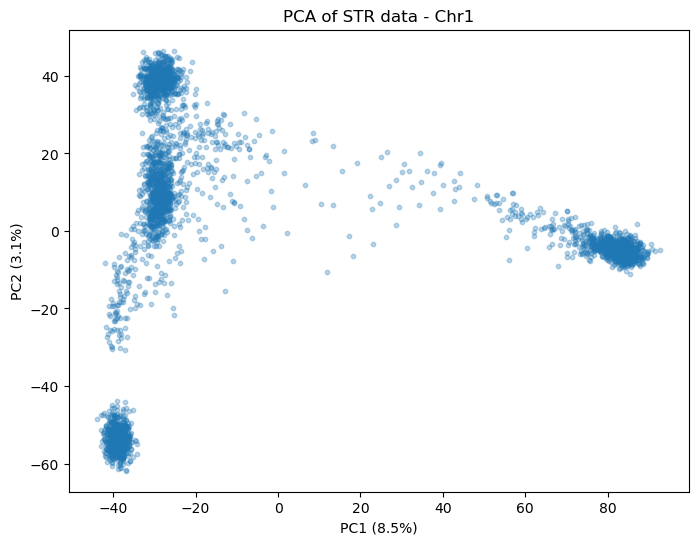

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=10)
plt.xlabel("PC1 (8.5%)")
plt.ylabel("PC2 (3.1%)")
plt.title("PCA of STR data - Chr1")
plt.show()

Or we ca also add color depending on the population labels (extracted from the sample_type.csv)

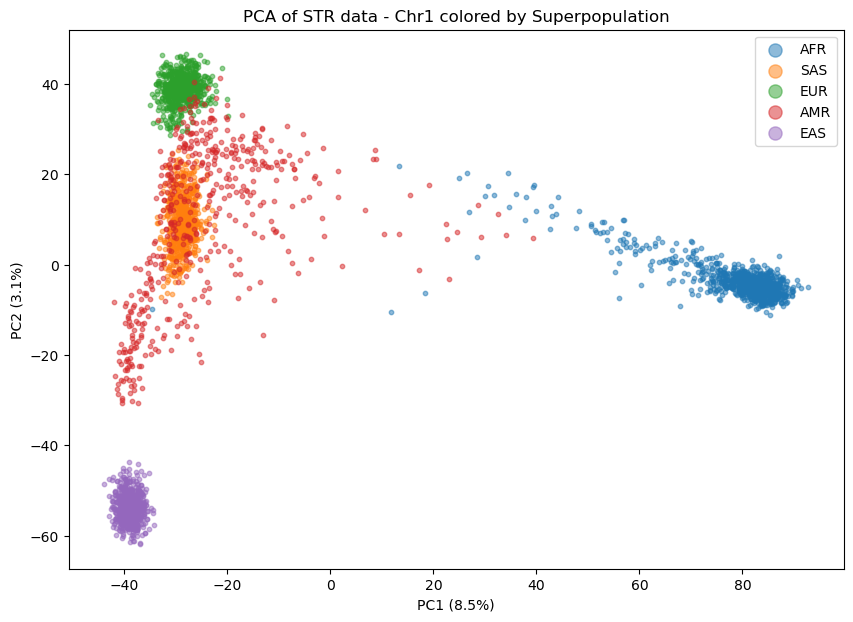

In [39]:
import pandas as pd

# Load labels
labels = pd.read_csv("sample_type.csv", index_col="sample")

# Align with your filtered matrix index
common_samples = str_matrix_filt.index.intersection(labels.index)
X_pca_aligned = X_pca[str_matrix_filt.index.isin(common_samples)]
labels_aligned = labels.loc[common_samples]

# Plot colored by Superpopulation
superpops = labels_aligned["Superpopulation"].values
unique_pops = labels_aligned["Superpopulation"].unique()

plt.figure(figsize=(10, 7))
for pop in unique_pops:
    mask = superpops == pop
    plt.scatter(X_pca_aligned[mask, 0], X_pca_aligned[mask, 1], 
                label=pop, alpha=0.5, s=10)

plt.xlabel("PC1 (8.5%)")
plt.ylabel("PC2 (3.1%)")
plt.title("PCA of STR data - Chr1 colored by Superpopulation")
plt.legend(markerscale=3)
plt.show()

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [41]:
# Use first 5 PCs
X_cluster = X_pca[:, :5]

# Try different k values
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels_km)
    print(f"k={k}: silhouette score = {sil:.3f}")

k=2: silhouette score = 0.613
k=3: silhouette score = 0.639
k=4: silhouette score = 0.643
k=5: silhouette score = 0.715
k=6: silhouette score = 0.692
k=7: silhouette score = 0.642


k=5 is the clear winner with 0.715 — and it perfectly matches the 5 superpopulations biologically. That's a really strong result, it means the STR data naturally separates into 5 groups without even using the labels. Similar as seen with SNP data in the previous exercise.

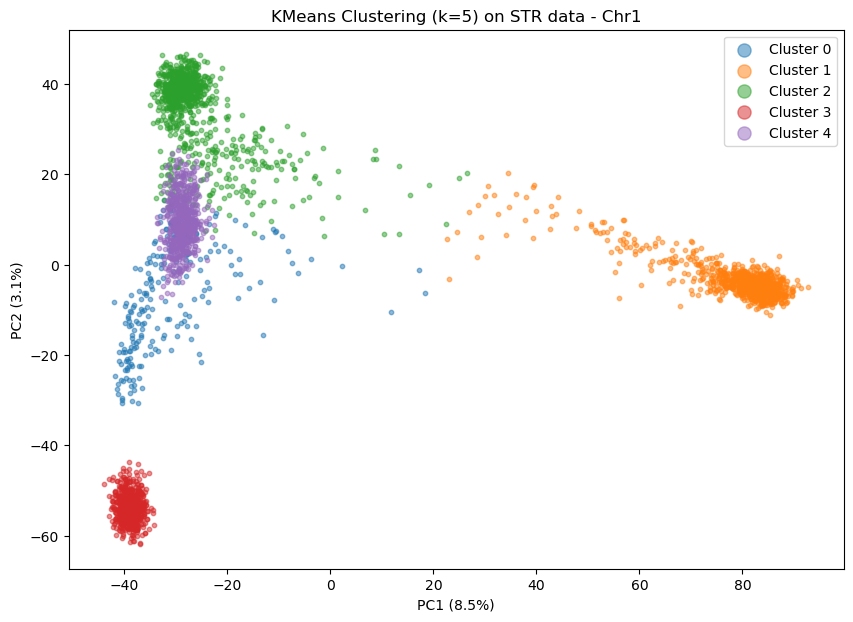

In [42]:
# Fit final model with k=5
km = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_cluster)

# Plot clusters
plt.figure(figsize=(10, 7))
for c in range(5):
    mask = cluster_labels == c
    plt.scatter(X_pca_aligned[mask, 0], X_pca_aligned[mask, 1],
                label=f"Cluster {c}", alpha=0.5, s=10)

plt.xlabel("PC1 (8.5%)")
plt.ylabel("PC2 (3.1%)")
plt.title("KMeans Clustering (k=5) on STR data - Chr1")
plt.legend(markerscale=3)
plt.show()

### Step 5 - Supervised classification

To evaluate whether STR profiles from chr1 can predict population identity, a supervised classification analysis will be performed using a Random Forest classifier from sklearn package. The first 5 PCs from the PCA will be used as the input features, becuase they capture the most of the genetic variation. 


I have split the dataset into 80% training and 20% test sets (random_state is 42 - for reproducibility). This gave 2561 training samples and 641 test samples. The Random Forest Sclassifier was trained with 100 decision trees on the training set using the known superpopulation labels (AFR, AMR, EAS, EUR, SAS) as the target variable.


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [44]:
# Align labels with PCA output
X = X_pca[:, :5]  # use first 5 PCs
y = labels.loc[str_matrix_filt.index, "Superpopulation"] # make sure the labels are in the same order as your X_pca

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nDetailed results:")
print(classification_report(y_test, y_pred))

Accuracy: 0.992

Detailed results:
              precision    recall  f1-score   support

         AFR       0.99      0.99      0.99       190
         AMR       0.97      0.96      0.97        73
         EAS       1.00      1.00      1.00       116
         EUR       0.98      1.00      0.99       131
         SAS       1.00      1.00      1.00       131

    accuracy                           0.99       641
   macro avg       0.99      0.99      0.99       641
weighted avg       0.99      0.99      0.99       641



The classifier achieved an overall accuracy of 99.2% on the test set, rendering it very successful.

Per-population results showed that EAS and SAS were classified with perfect precision and recall (1.00), while AFR and EUR achieved 0.99 and 0.98 scores, respectively. AMR showed the lowest but still high performance (0.97), consistent with its known admixed ancestry. 

These results demonstrate that STR variation on chr1 alone contains sufficient population structure to almost perfectly reconstruct continental ancestry.

### Make a confusion matrix

I have made this matrix just for visualisation purposes to show difference in numbers between true negatives/positives and false positives/negatives.

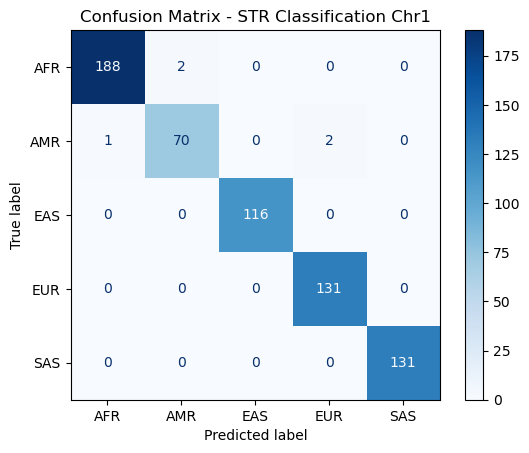

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=clf.classes_)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - STR Classification Chr1")
plt.show()

As I said previously the classifier did a very succesful job. Only 5 data points were wrongly labeled overall. 